<a href="https://colab.research.google.com/github/odabarani/stock_predictor/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

## Data Collection & Feature Engineering
Downloads 5 years of historical OHLCV data for a given ticker using yfinance.
Engineers the following technical indicators as model features:
- MA_5 / MA_20: 5-day and 20-day moving averages (trend signals)
- Momentum: % price change over last 5 days
- Volatility: 10-day rolling standard deviation
- Volume_Change: day-over-day volume % change
- Target: binary label — 1 if next day close is higher, 0 if not

In [3]:
df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")

df['MA_5']         = df['Close'].rolling(5).mean()
df['MA_20']        = df['Close'].rolling(20).mean()
df['Momentum']     = df['Close'].pct_change(5)
df['Volatility']   = df['Close'].rolling(10).std()
df['Volume_Change']= df['Volume'].pct_change()

df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df.dropna(inplace=True)
df.tail()

/tmp/ipykernel_3496/3612292001.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,MA_5,MA_20,Momentum,Volatility,Volume_Change,Target
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,
Date,,,,,,,,,,,
2023-12-22,191.609497,193.400885,190.985970,193.173239,37149600,193.181146,191.677264,-0.020094,1.791903,-0.200783,0
2023-12-26,191.065140,191.896500,190.847401,191.619380,28919300,192.618991,191.838589,-0.014498,1.812515,-0.221545,1
2023-12-27,191.164093,191.510500,189.125276,190.510890,48087700,191.868787,191.974677,-0.019244,1.967568,0.662824,1
2023-12-28,191.589676,192.658574,191.183888,192.143916,34049900,191.621353,192.183015,-0.006416,1.865333,-0.291921,0
2023-12-29,190.550446,192.401214,189.758668,191.906355,42672100,191.195770,192.310686,-0.011044,1.709375,0.253222,0


## Model Training
Trains a Random Forest Classifier on the engineered features.
Uses an 80/20 chronological train/test split — no shuffling to preserve
time-series order. Returns the trained model and test set for evaluation.

In [7]:
features = ['MA_5', 'MA_20', 'Momentum', 'Volatility', 'Volume_Change']
X = df[features]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.4637096774193548
              precision    recall  f1-score   support

           0       0.43      0.73      0.55       109
           1       0.55      0.25      0.34       139

    accuracy                           0.46       248
   macro avg       0.49      0.49      0.45       248
weighted avg       0.50      0.46      0.43       248



## Visualization
Builds an interactive Plotly chart displaying closing price alongside
the 5-day and 20-day moving averages for the selected ticker.

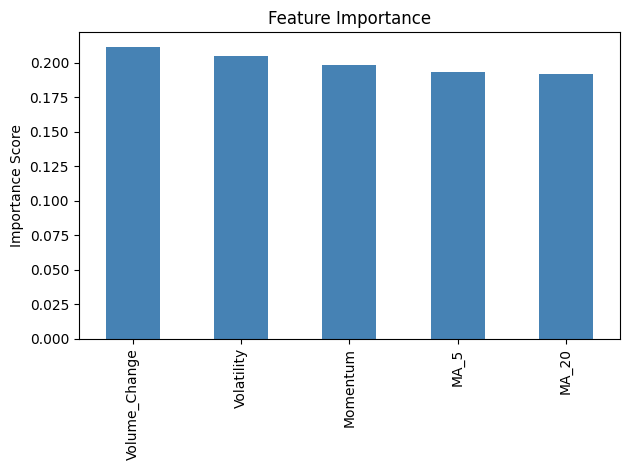

In [15]:
importances = model.feature_importances_
feat_df = pd.Series(importances, index=features).sort_values(ascending=False)

feat_df.plot(kind='bar', title='Feature Importance', color='steelblue')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

## Prediction
Takes the most recent row of feature data and runs it through the trained
model to generate a next-day price direction prediction (up or down).

In [14]:
def train_model(df):
    features = ['MA_5', 'MA_20', 'Momentum', 'Volatility', 'Volume_Change']
    X = df[features]
    y = df['Target']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)

    return model, accuracy, X_test, y_test

## Main Application
Entry point for the app. Takes a ticker input, runs the full pipeline (data collection, feature engineering, model training, visualization,
and prediction) and displays results to the user.

In [16]:
def plot_stock(df, ticker):
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=df.index, y=df['Close'].squeeze(),
        name='Close Price',
        line=dict(color='#2196F3', width=2)
    ))

    fig.add_trace(go.Scatter(
        x=df.index, y=df['MA_5'].squeeze(),
        name='5-Day MA',
        line=dict(color='#FF9800', width=1.5, dash='dot')
    ))

    fig.add_trace(go.Scatter(
        x=df.index, y=df['MA_20'].squeeze(),
        name='20-Day MA',
        line=dict(color='#4CAF50', width=1.5, dash='dash')
    ))

    fig.update_layout(
        title=f'{ticker} — Price & Moving Averages',
        xaxis_title='Date',
        yaxis_title='Price (USD)',
        template='plotly_dark',
        hovermode='x unified',
        legend=dict(orientation='h', yanchor='bottom', y=1.02)
    )

    fig.show()

In [17]:
def predict(model, df):
    features = ['MA_5', 'MA_20', 'Momentum', 'Volatility', 'Volume_Change']

    latest = df[features].iloc[-1].values.reshape(1, -1)
    prediction = model.predict(latest)[0]
    probability = model.predict_proba(latest)[0]

    direction = "📈 UP" if prediction == 1 else "📉 DOWN"
    confidence = round(max(probability) * 100, 2)

    return direction, confidence

In [22]:
def generate_signal(prediction, confidence):

    if prediction == 1 and confidence > 0.60:
        return "BUY"

    elif prediction == 0 and confidence > 0.60:
        return "SELL"

    else:
        return "HOLD"

In [41]:
def get_stock_data(ticker):
    df = yf.download(ticker, start="2019-01-01", end="2026-04-20")

    df['MA_5']         = df['Close'].rolling(5).mean()
    df['MA_20']        = df['Close'].rolling(20).mean()
    df['Momentum']     = df['Close'].pct_change(5)
    df['Volatility']   = df['Close'].rolling(10).std()
    df['Volume_Change']= df['Volume'].pct_change()

    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    df.dropna(inplace=True)
    return df

ticker = input("Enter a stock ticker (e.g. AAPL, TSLA, NVDA): ").upper()

print(f"\nFetching data for {ticker}...")
df = get_stock_data(ticker)

print("Training model...")
model, accuracy, X_test, y_test = train_model(df)

print(f"Model Accuracy: {round(accuracy * 100, 2)}%\n")

plot_stock(df, ticker)

direction, confidence = predict(model, df)

# convert string → numeric signal input
prediction_numeric = 1 if "UP" in direction else 0

signal = generate_signal(prediction_numeric, confidence)

print(f"Prediction for tomorrow: {direction}")
print(f"Confidence: {confidence}%")
print(f"Signal: {signal}")

Enter a stock ticker (e.g. AAPL, TSLA, NVDA): NVDA


/tmp/ipykernel_3496/583783671.py:2: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


Fetching data for NVDA...
Training model...


Model Accuracy: 54.55%

Prediction for tomorrow: 📉 DOWN
Confidence: 57.0%
Signal: HOLD
